# Netflix Content Analysis — 02 Analysis

Movies vs shows, where content comes from, how the catalog grew, and top genres.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()

## 1. Movies vs TV Shows

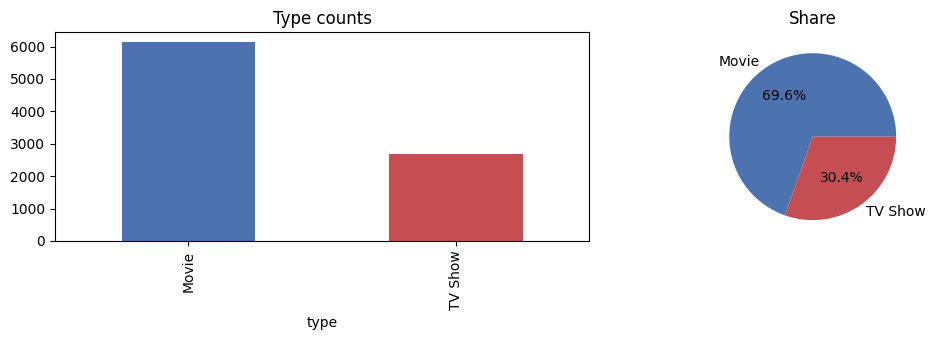

{'Movie': 6131, 'TV Show': 2676}


In [2]:
vc=df['type'].value_counts()
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
vc.plot(kind='bar',ax=ax[0],color=['#4c72b0','#c44e52']); ax[0].set_title('Type counts')
ax[1].pie(vc,labels=vc.index,autopct='%1.1f%%',colors=['#4c72b0','#c44e52']); ax[1].set_title('Share')
plt.tight_layout(); plt.show()
print(vc.to_dict())

## 2. Top producing countries

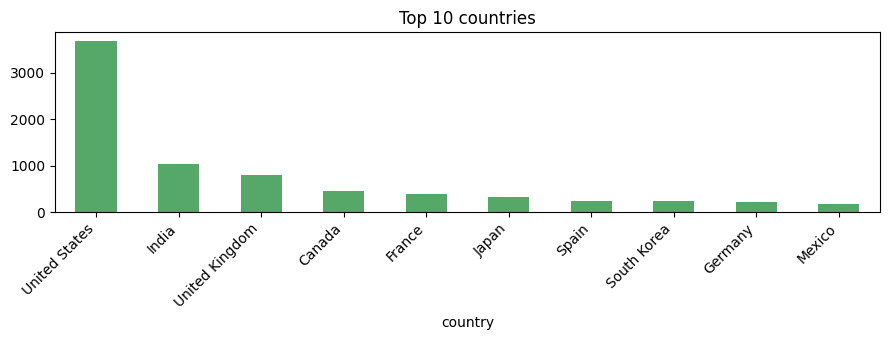

In [3]:
cc=utils.top_counts(df['country'],10,sep=',')
fig,ax=plt.subplots(figsize=(9,3.5)); cc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top 10 countries'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 3. Catalog growth (titles added per year)

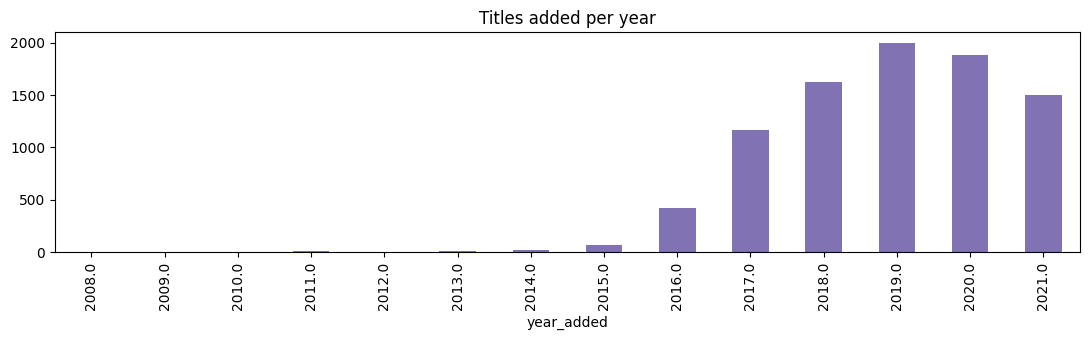

peak year: 2019 = 1999 titles


In [4]:
df['year_added']=pd.to_datetime(df['date_added'],errors='coerce').dt.year
ga=df['year_added'].value_counts().sort_index()
fig,ax=plt.subplots(figsize=(11,3.5)); ga.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Titles added per year'); plt.tight_layout(); plt.show()
print('peak year:',int(ga.idxmax()),'=',int(ga.max()),'titles')

## 4. Top genres & rating mix

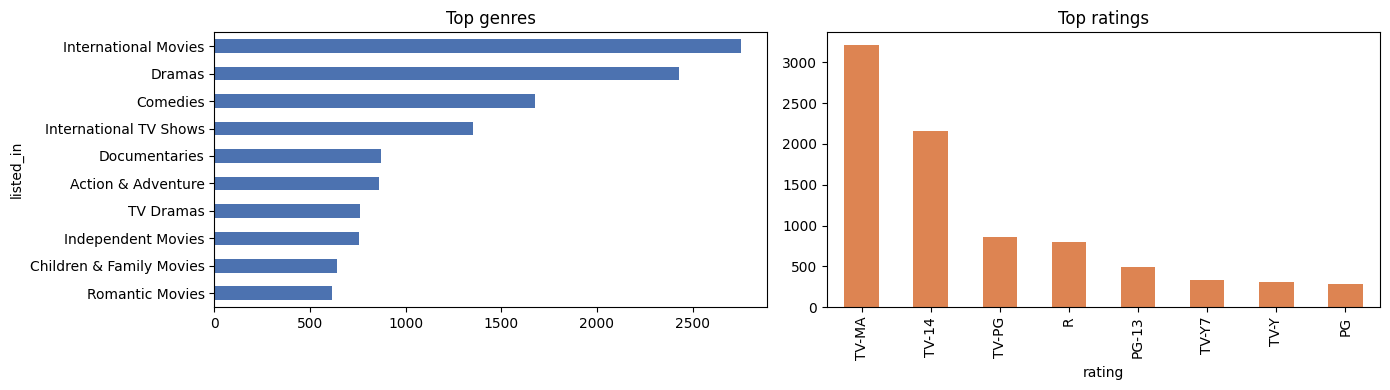

In [5]:
g=utils.top_counts(df['listed_in'],10,sep=',')
fig,ax=plt.subplots(1,2,figsize=(14,4))
g.plot(kind='barh',ax=ax[0],color='#4c72b0'); ax[0].set_title('Top genres'); ax[0].invert_yaxis()
df['rating'].value_counts().head(8).plot(kind='bar',ax=ax[1],color='#dd8452'); ax[1].set_title('Top ratings')
plt.tight_layout(); plt.show()

## 5. Key findings

- **~70% Movies (6,131) vs ~30% TV Shows (2,676).**
- **US dominates** production (3,689 titles), then India (1,046) and the UK (804) — Netflix's India investment is visible.
- **Catalog additions peaked in 2019 (~1,999 titles/yr)** then dipped — growth slowed after 2019.
- **International Movies, Dramas, and Comedies** are the largest genres; TV-MA / TV-14 dominate ratings (mature-leaning catalog).
- Netflix is movie-heavy, US-centric but globalizing, and matured its content pace post-2019.